# Implementation of MCP Neuron for AND and OR Function.

In [1]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)
  state_neuron = []

  # Element-wise addition and threshold check
  for x1, x2 in zip(X1, X2):
      total = x1 + x2
      if total >= T:
          state_neuron.append(1)
      else:
          state_neuron.append(0)

  return state_neuron

In [2]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [3]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.

    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.

    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)

    state_neuron = []

    # Element-wise addition and threshold check
    for x1, x2 in zip(X1, X2):
        total = x1 + x2
        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [4]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


**Question 1: Limitations of MCP Neurons**

The McCulloch-Pitts (MCP) neuron is a simple binary threshold model, but it has several important limitations:

**Only handles linearly separable problems**

MCP neurons cannot solve problems where data is not linearly separable (e.g., XOR).

**Binary inputs and outputs only**

Inputs and outputs are restricted to 0 or 1, making it unsuitable for real-valued data.

**No learning capability**

We must manually set weights and threshold; the neuron does not learn from data.

**Fixed threshold**

The threshold value is predefined and not adaptive.


**No concept of weights in basic form**

The simplest MCP model assumes equal weights, limiting flexibility.

**No handling of uncertainty/noise**

It cannot deal with noisy or probabilistic data.

**Single-layer limitation**

A single MCP neuron cannot model complex relationships.

# Implementation for 0 Vs. 1 Classification.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI_Machine_Learning/Week3/mnist_0_and_1.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Mounted at /content/drive
Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


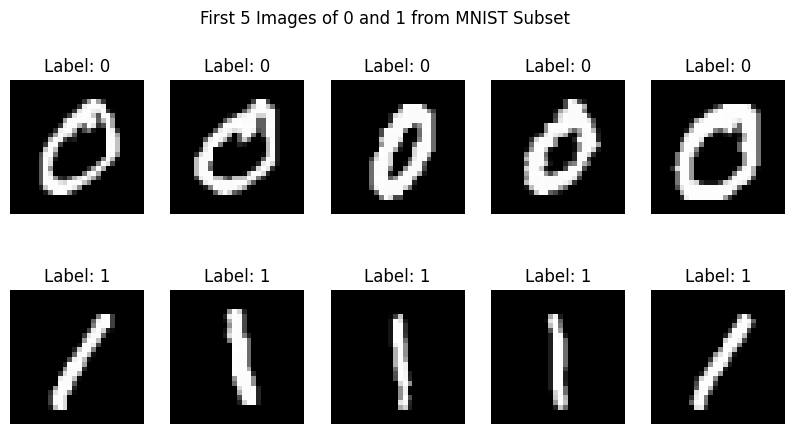

In [6]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [7]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

## Step - 3 - Make a Decision function:

In [8]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, -1)
    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [9]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    for _ in range(epochs):
        for i in range(len(X)):
            # Linear output
            linear_output = np.dot(X[i], weights) + bias

            # Step activation
            y_pred = 1 if linear_output >= 0 else 0

            # Update rule
            update = learning_rate * (y[i] - y_pred)
            weights = weights + update * X[i]
            bias = bias + update

    # Compute final predictions for accuracy
    predictions = np.where(np.dot(X, weights) + bias >= 0, 1, 0)
    accuracy = np.sum(predictions == y)


    return weights, bias, accuracy


## Training the Perceptron

In [10]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  12665


## Step 5: Visualize Misclassified Images

In [11]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


##Task 3: Perceptron Algorithm for 3 vs 5 Classification.

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


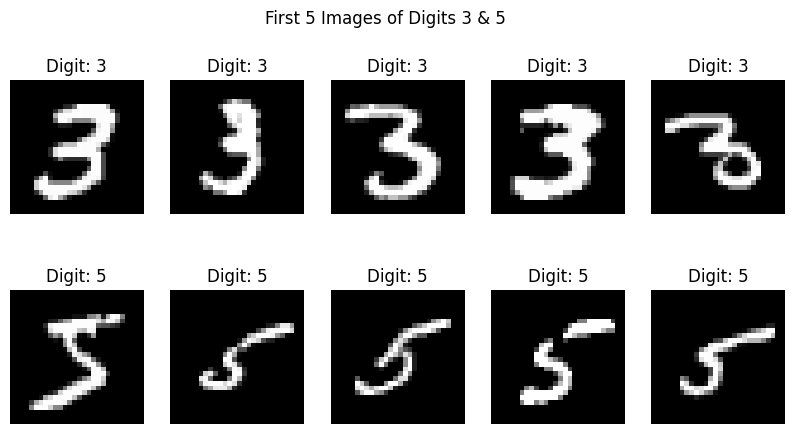

In [32]:
# Load dataset
df_3_5 = pd.read_csv("/content/drive/MyDrive/AI_Machine_Learning/Week3/mnist_3_and_5.csv")

# Separate features and labels
X = df_3_5.drop(columns=["label"]).values  # pixel values
y = df_3_5["label"].values  # labels (3 or 5)

# Print shapes to understand the dataset dimensions
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

# Extract images of digit 3 and digit 5
images_3 = X[y == 3]
images_5 = X[y == 5]

# Plot first 5 images of each class
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Digit: 3")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Digit: 5")
    axes[1, i].axis("off")

plt.suptitle("First 5 Images of Digits 3 & 5")
plt.show()

## Step - 2 - Initializing the Weights:

In [33]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 pixels
bias = 0
learning_rate = 0.1
epochs = 100

# Convert labels: 3 → 0, and 5 → 1
y_binary = np.where(y == 5, 1, 0)

## Step - 3 - Make a Decision function:

In [34]:
def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    return np.where(predictions >= 0, 1, 0)

## Step - 4 - Implement the Perceptron Learning Algorithm

In [35]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    for _ in range(epochs):
        for i in range(len(X)):

            # Linear output
            linear_output = np.dot(X[i], weights) + bias

            # Predicted label using step function
            y_pred = 1 if linear_output >= 0 else 0

            # Update rule
            update = learning_rate * (y[i] - y_pred)
            weights = weights + update * X[i]
            bias = bias + update

    # Final accuracy
    predictions = np.where(np.dot(X, weights) + bias >= 0, 1, 0)
    accuracy = np.mean(predictions == y)

    return weights, bias, accuracy

## Training the Perceptron

In [36]:
weights, bias, accuracy = train_perceptron(X, y_binary, weights, bias)

print("Final Training Accuracy:", accuracy)

Final Training Accuracy: 0.986866107260124


## Step 5: Visualize Misclassified Images

Total Misclassified: 36


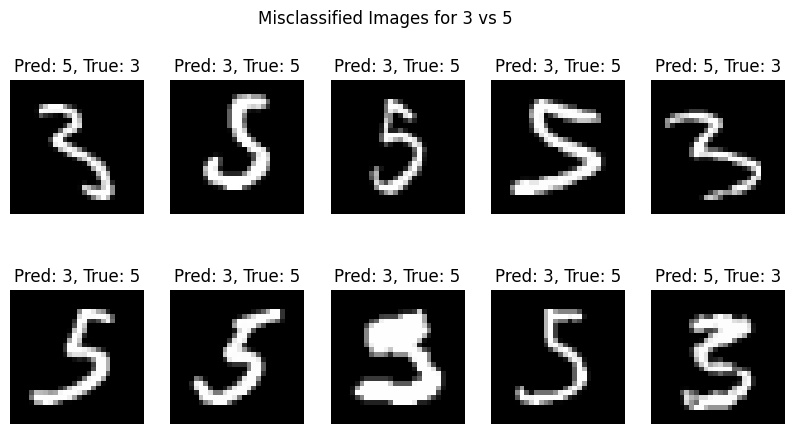

In [41]:
# Find all misclassified samples
misclassified_idx = np.where(predictions != y_binary)[0]

print("Total Misclassified:", len(misclassified_idx))

#Visualize the first 10 misclassified images
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    # Loop over the first 10 misclassified indices
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 images

        # Display the misclassified image (reshape 784 → 28×28)
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")

        # Map 0→3, 1→5
        pred_digit = 3 if predictions[idx] == 0 else 5
        true_digit = 3 if y_binary[idx] == 0 else 5

        # Predicted digit vs. True digit
        ax.set_title(f"Pred: {pred_digit}, True: {true_digit}")
        # Remove axis markings for cleaner visualization
        ax.axis("off")

    plt.suptitle("Misclassified Images for 3 vs 5")
    plt.show()
else:
    print("All images were correctly classified!")

The perceptron model was able to classify most images of digits 3 and 5 correctly, but it still made several mistakes. This shows that digits 3 and 5 overlap in shape and are not perfectly linearly separable. Therefore, a simple perceptron (which uses a linear decision boundary) cannot fully separate these two classes, leading to misclassified images.